In [56]:
import os
print("JAVA_HOME =", os.environ.get("JAVA_HOME"))
print("SPARK_HOME =", os.environ.get("SPARK_HOME"))
print("HADOOP_HOME =", os.environ.get("HADOOP_HOME"))
print("PATH =", os.environ.get("PATH")[:500])

JAVA_HOME = D:\software\java8
SPARK_HOME = D:\software\spark-3.5.8-bin-hadoop3
HADOOP_HOME = D:\software\hadoop
PATH = D:\install\anaconda\envs\spark_cassandra;D:\install\anaconda\envs\spark_cassandra\Library\mingw-w64\bin;D:\install\anaconda\envs\spark_cassandra\Library\usr\bin;D:\install\anaconda\envs\spark_cassandra\Library\bin;D:\install\anaconda\envs\spark_cassandra\Scripts;D:\install\anaconda\envs\spark_cassandra\bin;D:\install\anaconda\condabin;C:\Program Files (x86)\Common Files\Oracle\Java\java8path;C:\Program Files (x86)\Common Files\Oracle\Java\javapath;D:\software\apache-cassandra-3.11.19\bin;D:\inst


---
## Environment Versions

- **Python**: 3.10
- **Apache Spark**: 3.5.8
- **Apache Cassandra**: 3.11.19
- **Libraries**: `pyspark`, `cassandra-driver`
- **Dataset**: MovieLens 100K
---

In [57]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from pyspark.sql.types import *
from cassandra.cluster import Cluster
import pandas as pd
import matplotlib.pyplot as plt

os.environ["PYSPARK_PYTHON"] = "python"
os.environ["PYSPARK_DRIVER_PYTHON"] = "python"

# 2. create Spark Session
spark = SparkSession.builder \
    .appName("MovieLensCassandra") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext

spark.sparkContext.setLogLevel("WARN")

---
## Loading and parsing the MovieLens dataset via RDD → DataFrame

In [58]:
from pyspark.sql import Row
from pyspark.sql.functions import col
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, LongType

# u.user
rdd_user = sc.textFile("D:/dataset/ml-100k/u.user")
df_user = rdd_user.map(lambda x: x.split("|")) \
    .map(lambda r: Row(user_id=int(r[0]), age=int(r[1]), gender=r[2], occupation=r[3])) \
    .toDF()

# u.data
rdd_data = sc.textFile("D:/dataset/ml-100k/u.data")
df_rating = rdd_data.map(lambda x: x.split("\t")) \
    .map(lambda r: Row(user_id=int(r[0]), movie_id=int(r[1]), rating=int(r[2]))) \
    .toDF()

# u.item
rdd_item = sc.textFile("D:/dataset/ml-100k/u.item")
df_movie = rdd_item.map(lambda x: x.split("|")) \
    .map(lambda r: Row(
        movie_id=int(r[0]), title=r[1],
        action=int(r[6]), adventure=int(r[7]), animation=int(r[8]),
        children=int(r[9]), comedy=int(r[10]), crime=int(r[11]),
        documentary=int(r[12]), drama=int(r[13]), fantasy=int(r[14]),
        noir=int(r[15]), horror=int(r[16]), musical=int(r[17]),
        mystery=int(r[18]), romance=int(r[19]), sci_fi=int(r[20]),
        thriller=int(r[21]), war=int(r[22]), western=int(r[23])
    )).toDF()

df_user.cache()
df_rating.cache()
df_movie.cache()

# show
df_user.show(3)
df_rating.show(3)
df_movie.show(3)

+-------+---+------+----------+
|user_id|age|gender|occupation|
+-------+---+------+----------+
|      1| 24|     M|technician|
|      2| 53|     F|     other|
|      3| 23|     M|    writer|
+-------+---+------+----------+
only showing top 3 rows

+-------+--------+------+
|user_id|movie_id|rating|
+-------+--------+------+
|    196|     242|     3|
|    186|     302|     3|
|     22|     377|     1|
+-------+--------+------+
only showing top 3 rows

+--------+-----------------+------+---------+---------+--------+------+-----+-----------+-----+-------+----+------+-------+-------+-------+------+--------+---+-------+
|movie_id|            title|action|adventure|animation|children|comedy|crime|documentary|drama|fantasy|noir|horror|musical|mystery|romance|sci_fi|thriller|war|western|
+--------+-----------------+------+---------+---------+--------+------+-----+-----------+-----+-------+----+------+-------+-------+-------+------+--------+---+-------+
|       1| Toy Story (1995)|     0|     

In [59]:
# connect Cassandra
cluster = Cluster(["127.0.0.1"])
session = cluster.connect()
session.execute("CREATE KEYSPACE IF NOT EXISTS movielens WITH replication = {'class':'SimpleStrategy','replication_factor':1}")
session = cluster.connect("movielens")

# create table
session.execute("CREATE TABLE IF NOT EXISTS movie_avg_rating (movie_id INT PRIMARY KEY, title TEXT, avg_rating DOUBLE, count_rating INT)")
session.execute("CREATE TABLE IF NOT EXISTS top_movies (movie_id INT PRIMARY KEY, title TEXT, avg_rating DOUBLE)")
session.execute("CREATE TABLE IF NOT EXISTS user_fav_genre (user_id INT PRIMARY KEY, fav_genre TEXT, rating_count INT)")
session.execute("CREATE TABLE IF NOT EXISTS users_under_20 (user_id INT PRIMARY KEY, age INT, gender TEXT, occupation TEXT)")
session.execute("CREATE TABLE IF NOT EXISTS scientist_30_40 (user_id INT PRIMARY KEY, age INT, gender TEXT, occupation TEXT)")


---
## 1. Calculate the average rating for each movie.

In [60]:
# calculate
df_avg = df_rating.groupBy("movie_id") \
    .agg(
        avg("rating").alias("avg_rating"),
        count("rating").alias("count_rating")
    )

# marge
df_avg = df_avg.join(df_movie.select("movie_id", "title"), "movie_id")

# save into Cassandra
data = df_avg.collect()
for row in data:
    session.execute("""
        INSERT INTO movie_avg_rating (movie_id, title, avg_rating, count_rating)
        VALUES (%s, %s, %s, %s)
    """, (row.movie_id, row.title, row.avg_rating, row.count_rating))

# show
df_avg.orderBy(desc("avg_rating")).show(10, truncate=False)

+--------+----------+------------+-------------------------------------------------+
|movie_id|avg_rating|count_rating|title                                            |
+--------+----------+------------+-------------------------------------------------+
|1536    |5.0       |1           |Aiqing wansui (1994)                             |
|1500    |5.0       |2           |Santa with Muscles (1996)                        |
|814     |5.0       |1           |Great Day in Harlem, A (1994)                    |
|1599    |5.0       |1           |Someone Else's America (1995)                    |
|1189    |5.0       |3           |Prefontaine (1997)                               |
|1653    |5.0       |1           |Entertaining Angels: The Dorothy Day Story (1996)|
|1293    |5.0       |3           |Star Kid (1997)                                  |
|1122    |5.0       |1           |They Made Me a Criminal (1939)                   |
|1201    |5.0       |1           |Marlene Dietrich: Shadow and Li

In [61]:
# Demonstrating Spark SQL operations
df_avg.createOrReplaceTempView("movie_avg")
spark.sql("""
    SELECT movie_id, title, avg_rating, count_rating
    FROM movie_avg
    ORDER BY avg_rating DESC
    LIMIT 10
""").show()

+--------+--------------------+----------+------------+
|movie_id|               title|avg_rating|count_rating|
+--------+--------------------+----------+------------+
|    1536|Aiqing wansui (1994)|       5.0|           1|
|    1189|  Prefontaine (1997)|       5.0|           3|
|    1599|Someone Else's Am...|       5.0|           1|
|    1293|     Star Kid (1997)|       5.0|           3|
|     814|Great Day in Harl...|       5.0|           1|
|    1653|Entertaining Ange...|       5.0|           1|
|    1500|Santa with Muscle...|       5.0|           2|
|    1122|They Made Me a Cr...|       5.0|           1|
|    1201|Marlene Dietrich:...|       5.0|           1|
|    1467|Saint of Fort Was...|       5.0|           2|
+--------+--------------------+----------+------------+



This task calculates the average rating and rating count for every movie in the dataset.
The results reflect overall movie popularity and engagement, and are stored in the `movie_avg_rating` table in Cassandra.

---
## 2. Identify the top ten movies with the highest average ratings. 

In [62]:
# calculate
top10 = df_avg.filter(col("count_rating") >= 20) \
    .orderBy(desc("avg_rating")) \
    .limit(10)

# save
top10_data = top10.collect()
for row in top10_data:
    session.execute("""
        INSERT INTO top_movies (movie_id, title, avg_rating)
        VALUES (%s, %s, %s)
    """, (row.movie_id, row.title, row.avg_rating))

top10.show(truncate=False)

+--------+------------------+------------+------------------------------------------------------+
|movie_id|avg_rating        |count_rating|title                                                 |
+--------+------------------+------------+------------------------------------------------------+
|408     |4.491071428571429 |112         |Close Shave, A (1995)                                 |
|318     |4.466442953020135 |298         |Schindler's List (1993)                               |
|169     |4.466101694915254 |118         |Wrong Trousers, The (1993)                            |
|483     |4.45679012345679  |243         |Casablanca (1942)                                     |
|114     |4.447761194029851 |67          |Wallace & Gromit: The Best of Aardman Animation (1996)|
|64      |4.445229681978798 |283         |Shawshank Redemption, The (1994)                      |
|603     |4.3875598086124405|209         |Rear Window (1954)                                    |
|12      |4.38576779

In [63]:
# Validating stored data with native Cassandra queries
# Sorting is performed in Python to work around Cassandra's ORDER BY limitations
rows = session.execute("SELECT * FROM top_movies")
sorted_rows = sorted(rows, key=lambda x: x.avg_rating, reverse=True)

for row in sorted_rows:
    print(f"movie_id: {row.movie_id}, title: {row.title}, avg_rating: {row.avg_rating}")

movie_id: 408, title: Close Shave, A (1995), avg_rating: 4.491071428571429
movie_id: 318, title: Schindler's List (1993), avg_rating: 4.466442953020135
movie_id: 169, title: Wrong Trousers, The (1993), avg_rating: 4.466101694915254
movie_id: 483, title: Casablanca (1942), avg_rating: 4.45679012345679
movie_id: 114, title: Wallace & Gromit: The Best of Aardman Animation (1996), avg_rating: 4.447761194029851
movie_id: 64, title: Shawshank Redemption, The (1994), avg_rating: 4.445229681978798
movie_id: 603, title: Rear Window (1954), avg_rating: 4.3875598086124405
movie_id: 12, title: Usual Suspects, The (1995), avg_rating: 4.385767790262173
movie_id: 50, title: Star Wars (1977), avg_rating: 4.3584905660377355
movie_id: 178, title: 12 Angry Men (1957), avg_rating: 4.344


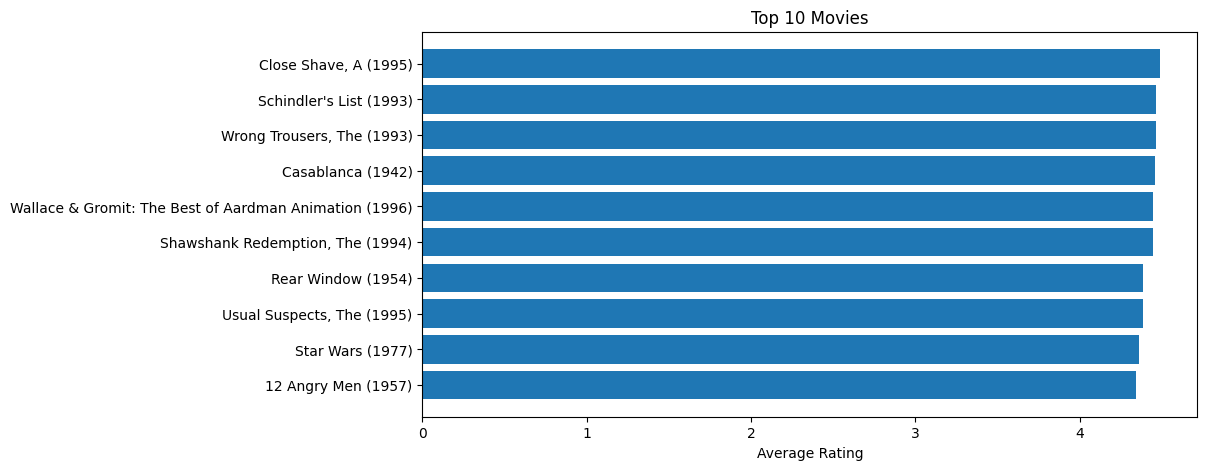

In [81]:
top_pd = top10.toPandas()
plt.figure(figsize=(10,5))
plt.barh(top_pd["title"], top_pd["avg_rating"])
plt.xlabel("Average Rating")
plt.title("Top 10 Movies")
plt.gca().invert_yaxis()
plt.savefig('top10_movies.png', dpi=300)
plt.show()

This bar chart shows the top 10 highest-rated movies, all receiving strong average ratings between 4.3 and 4.5. Classics from various genres dominate the list, reflecting broad user appeal and consistent high regard across different film types.

---
## 3. Identify users who have rated at least 50 movies and determine their favourite movie genre based on the genre they rated most frequently.

In [65]:
# frequency of rate
user_movie_count = df_rating.groupBy("user_id") \
    .agg(count("movie_id").alias("total_rated")) \
    .filter(col("total_rated") >= 50)

# transform
genres = ["action","adventure","animation","children","comedy","crime",
          "documentary","drama","fantasy","noir","horror","musical",
          "mystery","romance","sci_fi","thriller","war","western"]

genre_stack = ", ".join([f"'{g}', {g}" for g in genres])
df_movie_long = df_movie.selectExpr(
    "movie_id",
    f"stack({len(genres)}, {genre_stack}) as (genre, is_genre)"
).filter(col("is_genre") == 1)

# merge rate
user_genre = df_rating.join(df_movie_long, on="movie_id")
user_genre = user_genre.groupBy("user_id", "genre").count()

# choice the most type
window = Window.partitionBy("user_id").orderBy(desc("count"))
user_fav = user_genre.withColumn("rn", row_number().over(window)) \
    .filter(col("rn") == 1) \
    .select("user_id", col("genre").alias("fav_genre"), col("count").alias("rating_count"))

# remian user with >=5
user_fav = user_fav.join(user_movie_count, on="user_id")

user_fav_data = user_fav.collect()
for row in user_fav_data:
    session.execute("""
        INSERT INTO user_fav_genre (user_id, fav_genre, rating_count)
        VALUES (%s, %s, %s)
    """, (row.user_id, row.fav_genre, row.rating_count))


user_fav.show(10, truncate=False)

+-------+---------+------------+-----------+
|user_id|fav_genre|rating_count|total_rated|
+-------+---------+------------+-----------+
|1      |drama    |107         |272        |
|2      |drama    |35          |62         |
|3      |drama    |22          |54         |
|5      |comedy   |82          |175        |
|6      |drama    |104         |211        |
|7      |drama    |146         |403        |
|8      |action   |39          |59         |
|10     |drama    |81          |184        |
|11     |drama    |82          |181        |
|12     |drama    |24          |51         |
+-------+---------+------------+-----------+
only showing top 10 rows



In [66]:
# Validating stored data with native Cassandra queries
rows = session.execute("SELECT * FROM user_fav_genre LIMIT 10")
for r in rows:
    print(r)

Row(user_id=23, fav_genre='drama', rating_count=54)
Row(user_id=660, fav_genre='action', rating_count=91)
Row(user_id=893, fav_genre='action', rating_count=24)
Row(user_id=878, fav_genre='drama', rating_count=76)
Row(user_id=110, fav_genre='action', rating_count=50)
Row(user_id=91, fav_genre='drama', rating_count=46)
Row(user_id=128, fav_genre='drama', rating_count=85)
Row(user_id=363, fav_genre='drama', rating_count=108)
Row(user_id=251, fav_genre='action', rating_count=31)
Row(user_id=778, fav_genre='drama', rating_count=25)


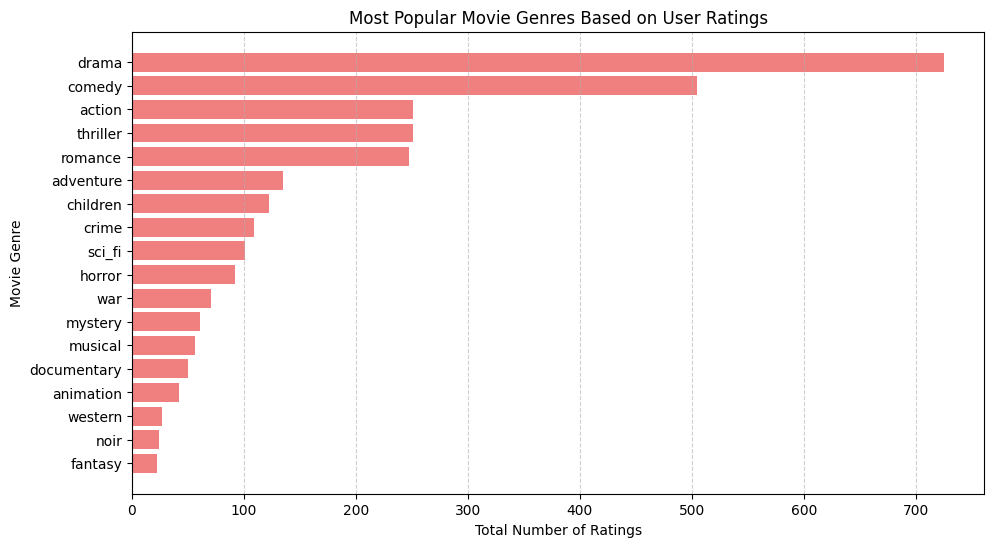

In [82]:
# Count total ratings per genre
genre_count = df_movie_long.groupBy("genre").count().orderBy("count", ascending=False)
genre_pd = genre_count.toPandas()

plt.figure(figsize=(11, 6))
plt.barh(genre_pd["genre"], genre_pd["count"], color="lightcoral")
plt.xlabel("Total Number of Ratings")
plt.ylabel("Movie Genre")
plt.title("Most Popular Movie Genres Based on User Ratings")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('most_popular_base_on_rate.png', dpi=300)
plt.show()

Drama and comedy are the most popular genres by far, with drama receiving over 700 ratings and comedy close to 500. Action, thriller, and romance follow, while genres like fantasy, noir, and western have the fewest ratings. This shows users clearly prefer character-driven and lighthearted stories.

---
## 4. Find all users who are less than 20 years old. 

In [67]:
under_20 = df_user.filter(col("age") < 20)

under_20_data = under_20.collect()
for row in under_20_data:
    session.execute("""
        INSERT INTO users_under_20 (user_id, age, gender, occupation)
        VALUES (%s, %s, %s, %s)
    """, (row.user_id, row.age, row.gender, row.occupation))

under_20.show()

+-------+---+------+-------------+
|user_id|age|gender|   occupation|
+-------+---+------+-------------+
|     30|  7|     M|      student|
|     36| 19|     F|      student|
|     52| 18|     F|      student|
|     57| 16|     M|         none|
|     67| 17|     M|      student|
|     68| 19|     M|      student|
|    101| 15|     M|      student|
|    110| 19|     M|      student|
|    142| 13|     M|        other|
|    179| 15|     M|entertainment|
|    206| 14|     F|      student|
|    221| 19|     M|      student|
|    223| 19|     F|      student|
|    246| 19|     M|      student|
|    257| 17|     M|      student|
|    258| 19|     F|      student|
|    262| 19|     F|      student|
|    270| 18|     F|      student|
|    281| 15|     F|      student|
|    289| 11|     M|         none|
+-------+---+------+-------------+
only showing top 20 rows



In [68]:
# Validating stored data with native Cassandra queries
rows = session.execute("SELECT * FROM users_under_20 LIMIT 20")
for r in rows:
    print(r)

Row(user_id=110, age=19, gender='M', occupation='student')
Row(user_id=849, age=15, gender='F', occupation='student')
Row(user_id=729, age=19, gender='M', occupation='student')
Row(user_id=631, age=18, gender='F', occupation='student')
Row(user_id=787, age=18, gender='F', occupation='student')
Row(user_id=646, age=17, gender='F', occupation='student')
Row(user_id=925, age=18, gender='F', occupation='salesman')
Row(user_id=619, age=17, gender='M', occupation='student')
Row(user_id=320, age=19, gender='M', occupation='student')
Row(user_id=461, age=15, gender='M', occupation='student')
Row(user_id=67, age=17, gender='M', occupation='student')
Row(user_id=642, age=18, gender='F', occupation='student')
Row(user_id=588, age=18, gender='F', occupation='student')
Row(user_id=30, age=7, gender='M', occupation='student')
Row(user_id=528, age=18, gender='M', occupation='student')
Row(user_id=674, age=13, gender='F', occupation='student')
Row(user_id=375, age=17, gender='M', occupation='entertain

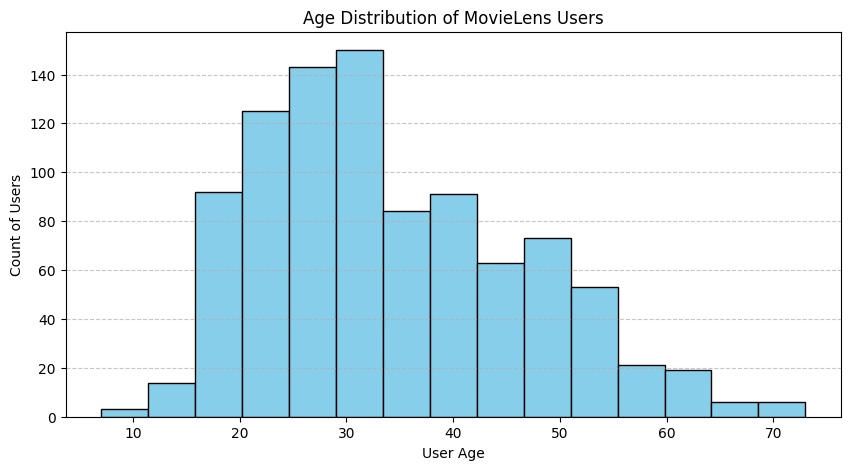

In [83]:
plt.figure(figsize=(10, 5))
# Collect age values from DataFrame
ages = df_user.select("age").rdd.flatMap(lambda x: x).collect()

# Plot histogram
plt.hist(ages, bins=15, color="skyblue", edgecolor="black")
plt.xlabel("User Age")
plt.ylabel("Count of Users")
plt.title("Age Distribution of MovieLens Users")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('age_distribution.png', dpi=300)
plt.show()

The dataset is dominated by young to middle-aged users, with the largest group being those in their late 20s and early 30s. User numbers decline steadily with age, showing the audience is mostly concentrated between 20 and 40 years old.

---
## 5. Find all users whose occupation is “scientist” and whose age is between 30 and 40 years old.

In [69]:
scientist = df_user.filter(
    (col("occupation") == "scientist") &
    (col("age") >= 30) &
    (col("age") <= 40)
)

scientist_data = scientist.collect()
for row in scientist_data:
    session.execute("""
        INSERT INTO scientist_30_40 (user_id, age, gender, occupation)
        VALUES (%s, %s, %s, %s)
    """, (row.user_id, row.age, row.gender, row.occupation))


scientist.show()

+-------+---+------+----------+
|user_id|age|gender|occupation|
+-------+---+------+----------+
|     40| 38|     M| scientist|
|     71| 39|     M| scientist|
|     74| 39|     M| scientist|
|    107| 39|     M| scientist|
|    183| 33|     M| scientist|
|    272| 33|     M| scientist|
|    309| 40|     M| scientist|
|    337| 37|     M| scientist|
|    430| 38|     M| scientist|
|    538| 31|     M| scientist|
|    543| 33|     M| scientist|
|    554| 32|     M| scientist|
|    643| 39|     M| scientist|
|    730| 31|     F| scientist|
|    874| 36|     M| scientist|
|    918| 40|     M| scientist|
+-------+---+------+----------+



In [70]:
# Validating stored data with native Cassandra queries
rows = session.execute("SELECT * FROM scientist_30_40 LIMIT 10")
for r in rows:
    print(r)

Row(user_id=874, age=36, gender='M', occupation='scientist')
Row(user_id=538, age=31, gender='M', occupation='scientist')
Row(user_id=730, age=31, gender='F', occupation='scientist')
Row(user_id=74, age=39, gender='M', occupation='scientist')
Row(user_id=183, age=33, gender='M', occupation='scientist')
Row(user_id=107, age=39, gender='M', occupation='scientist')
Row(user_id=918, age=40, gender='M', occupation='scientist')
Row(user_id=337, age=37, gender='M', occupation='scientist')
Row(user_id=554, age=32, gender='M', occupation='scientist')
Row(user_id=40, age=38, gender='M', occupation='scientist')


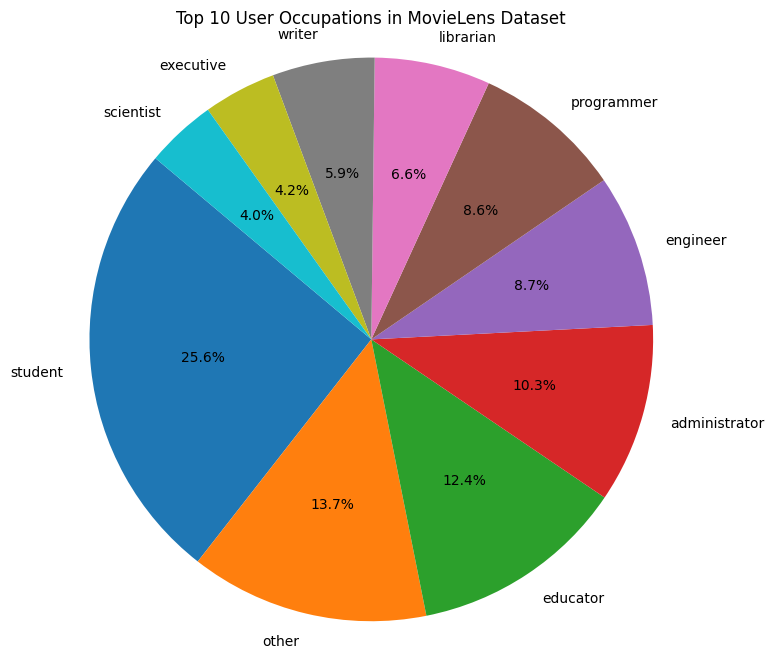

In [85]:
# Count users by occupation and take top 10
occupation_data = df_user.groupBy("occupation").count().orderBy("count", ascending=False).limit(10)
occupation_pd = occupation_data.toPandas()

plt.figure(figsize=(8, 8))
plt.pie(occupation_pd["count"], labels=occupation_pd["occupation"], autopct="%1.1f%%", startangle=140)
plt.title("Top 10 User Occupations in MovieLens Dataset")
plt.axis("equal")
plt.savefig('occupation.png', dpi=300)
plt.show()

Students make up the largest group, accounting for over a quarter of users. Educators, administrators, and engineers follow as the next most common occupations, while scientists and writers represent the smallest segments.

---
## Read the Cassandra tables back into Spark DataFrames

In [74]:
from cassandra.cluster import Cluster

# connect Cassandra
cluster = Cluster(["127.0.0.1"])
session = cluster.connect("movielens")

# check
tables = ["movie_avg_rating", "top_movies", "user_fav_genre", "users_under_20", "scientist_30_40"]

for table in tables:
    print(f"--- {table} ---")
    rows = session.execute(f"SELECT * FROM {table} LIMIT 3")
    for row in rows:
        print(row)
    print("")

# close
cluster.shutdown()

--- movie_avg_rating ---
Row(movie_id=1584, avg_rating=1.0, count_rating=1, title='Symphonie pastorale, La (1946)')
Row(movie_id=769, avg_rating=2.4523809523809526, count_rating=42, title='Congo (1995)')
Row(movie_id=1580, avg_rating=1.0, count_rating=1, title='Liebelei (1933)')

--- top_movies ---
Row(movie_id=114, avg_rating=4.447761194029851, title='Wallace & Gromit: The Best of Aardman Animation (1996)')
Row(movie_id=483, avg_rating=4.45679012345679, title='Casablanca (1942)')
Row(movie_id=178, avg_rating=4.344, title='12 Angry Men (1957)')

--- user_fav_genre ---
Row(user_id=23, fav_genre='drama', rating_count=54)
Row(user_id=660, fav_genre='action', rating_count=91)
Row(user_id=893, fav_genre='action', rating_count=24)

--- users_under_20 ---
Row(user_id=110, age=19, gender='M', occupation='student')
Row(user_id=849, age=15, gender='F', occupation='student')
Row(user_id=729, age=19, gender='M', occupation='student')

--- scientist_30_40 ---
Row(user_id=874, age=36, gender='M', oc

---
## Analytical queries using Spark SQL

In [76]:
top10.createOrReplaceTempView("top_movies")
print("=== Spark SQL: Top 10 Highest Rated Movies ===")
spark.sql("SELECT * FROM top_movies ORDER BY avg_rating DESC").show()

=== Spark SQL: Top 10 Highest Rated Movies ===
+--------+------------------+------------+--------------------+
|movie_id|        avg_rating|count_rating|               title|
+--------+------------------+------------+--------------------+
|     408| 4.491071428571429|         112|Close Shave, A (1...|
|     318| 4.466442953020135|         298|Schindler's List ...|
|     169| 4.466101694915254|         118|Wrong Trousers, T...|
|     483|  4.45679012345679|         243|   Casablanca (1942)|
|     114| 4.447761194029851|          67|Wallace & Gromit:...|
|      64| 4.445229681978798|         283|Shawshank Redempt...|
|     603|4.3875598086124405|         209|  Rear Window (1954)|
|      12| 4.385767790262173|         267|Usual Suspects, T...|
|      50|4.3584905660377355|         583|    Star Wars (1977)|
|     178|             4.344|         125| 12 Angry Men (1957)|
+--------+------------------+------------+--------------------+



In [86]:
session.shutdown()
cluster.shutdown()
spark.stop()